In [10]:
from auditoryforage.utils import open_pickle_file
file_name = '../data_files/compiled/3_data_behavior.pkl'
compiled_data = open_pickle_file(file_name)

In [11]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

# from irc.manager import IRCManager

# ############

# defaults = {
#     'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
#     'agent.model._target_': 'irc.model.FuncBeliefModel',
# }
# manager = IRCManager(defaults=defaults)

############

def count_no_elements(np_array, min_allowed, max_allowed):
    return len([elt for elt in list(np_array.flatten()) if elt >= min_allowed and elt <= max_allowed])

############

from auditoryforage.AF_env import AuditoryForaging
# env_param = [lick_cost, food_reward, attention_cost_coeff, attention_cost_temp, penalty_cost, iti_cost]
# env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
env = AuditoryForaging()


hit_count_list = []
miss_count_list = []
false_alarm_list = []
noise_time_before_lick_list = []
signal_time_before_lick_list = []
total_noise_time_list = []
total_signal_time_list = []

analysis_report = {}

for mouse in compiled_data:
    analysis_report[mouse] = {}
    for block_index in compiled_data[mouse]:
        analysis_report[mouse][block_index] = {}
        hit_count = 0 
        miss_count = 0 
        false_alarm_count = 0 
        noise_time_before_lick = 0 
        signal_time_before_lick = 0 
        total_noise_time = 0 
        total_signal_time = 0
        hit_reaction_time_list = []
        fa_reaction_time_list = []
        lick_time_list = []
        for trial in compiled_data[mouse][block_index]:
            if trial['rewards'][-1] > 0:
                hit_count += 1
                hit_reaction_time_list.append(count_no_elements(trial['states'], 1, env.no_signal_nodes))
                signal_time_before_lick += count_no_elements(trial['states'], 1, env.no_signal_nodes)
                lick_time_list.append(len(trial['states']))
            elif trial['states'][-1] > env.no_signal_nodes + 1:
                miss_count += 1
            elif trial['states'][-1] == env.no_signal_nodes + 1:
                false_alarm_count += 1
                fa_reaction_time_list.append(count_no_elements(trial['states'], 0, 0))
                noise_time_before_lick += count_no_elements(trial['states'], 0, 0)
                lick_time_list.append(len(trial['states']))
            else:
                print("Error somewhere")
            total_signal_time += count_no_elements(trial['states'], 1, env.no_signal_nodes)
            total_noise_time += count_no_elements(trial['states'], 0, 0)
        analysis_report[mouse][block_index]['hit_count'] = hit_count
        analysis_report[mouse][block_index]['miss_count'] = miss_count
        analysis_report[mouse][block_index]['false_alarm_count'] = false_alarm_count
        analysis_report[mouse][block_index]['noise_time_before_lick'] = noise_time_before_lick
        analysis_report[mouse][block_index]['signal_time_before_lick'] = signal_time_before_lick
        analysis_report[mouse][block_index]['total_noise_time'] = total_noise_time
        analysis_report[mouse][block_index]['total_signal_time'] = total_signal_time
        analysis_report[mouse][block_index]['no_trials'] = len(compiled_data[mouse][block_index])
        analysis_report[mouse][block_index]['hit_reaction_time_list'] = hit_reaction_time_list
        analysis_report[mouse][block_index]['fa_reaction_time_list'] = fa_reaction_time_list
        analysis_report[mouse][block_index]['lick_time_list'] = lick_time_list

############

from auditoryforage.utils import save_pickle_file

folder_name = './store/'
file_name = folder_name + 'analysis_report.pkl'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
save_pickle_file(analysis_report, file_name)

In [12]:
from auditoryforage.utils import open_pickle_file
file_name = './store/analysis_report.pkl'
analysis_report = open_pickle_file(file_name)

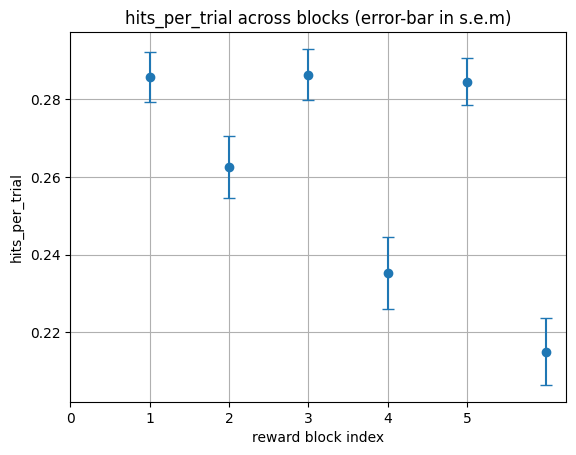

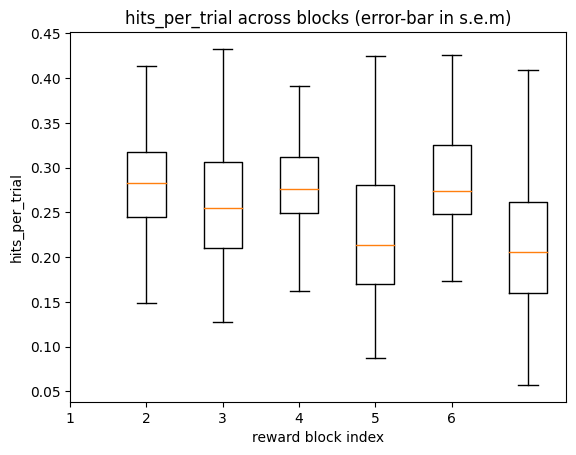

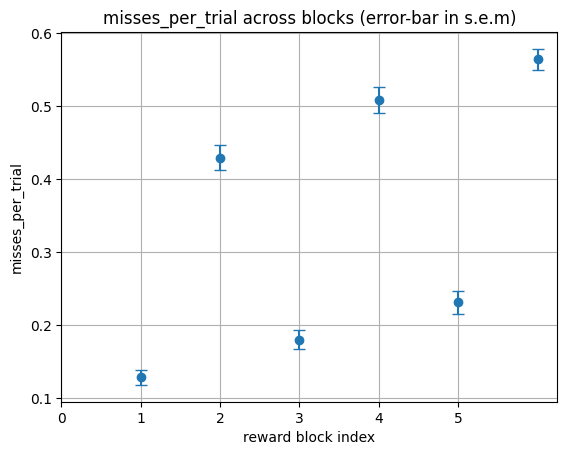

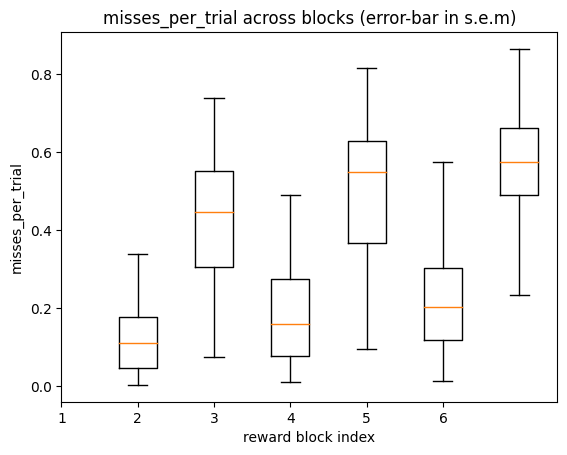

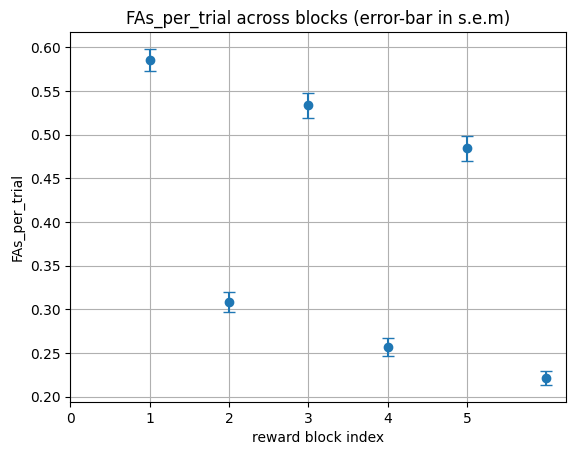

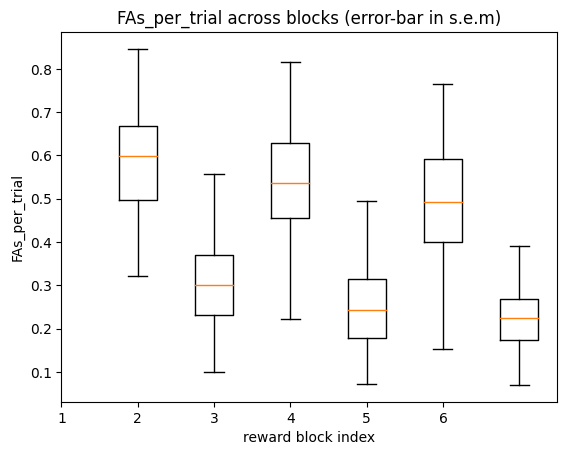

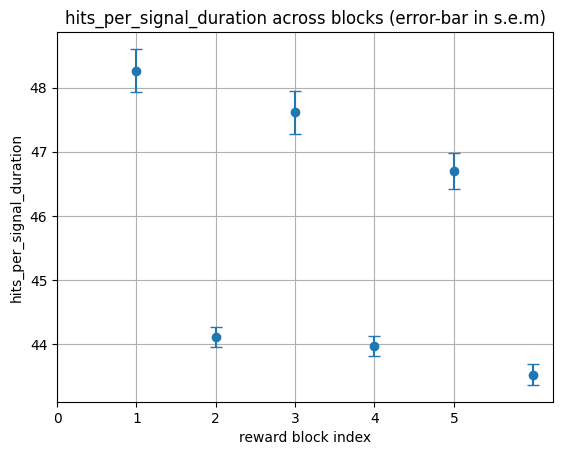

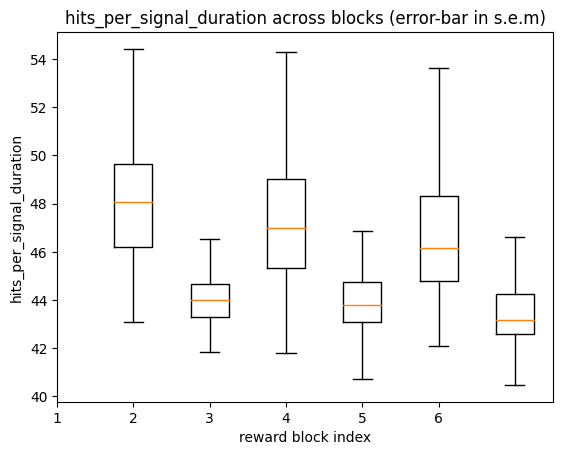

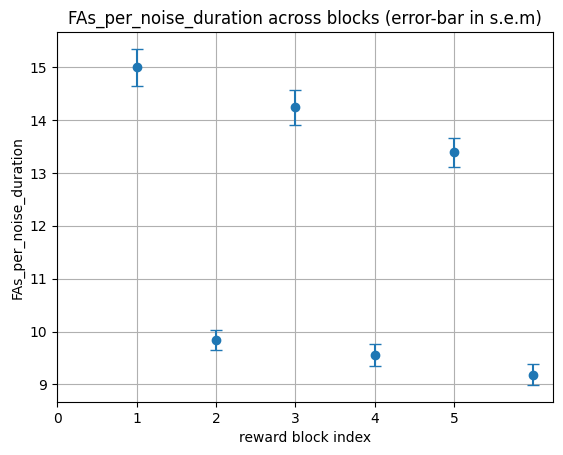

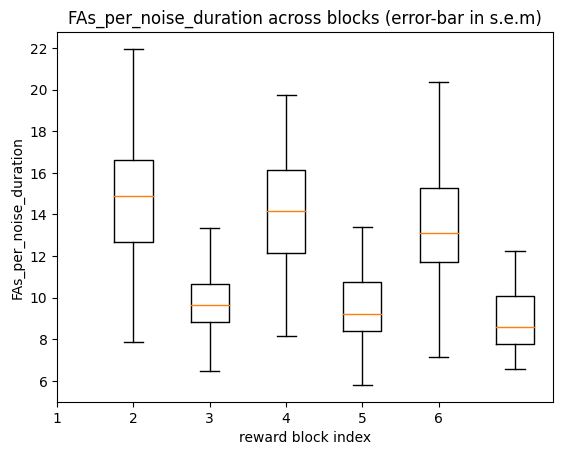

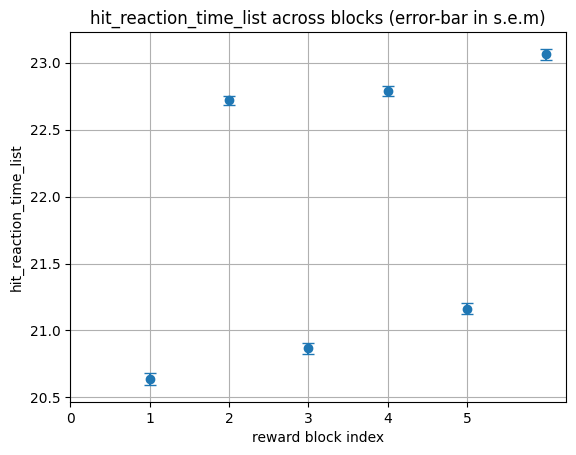

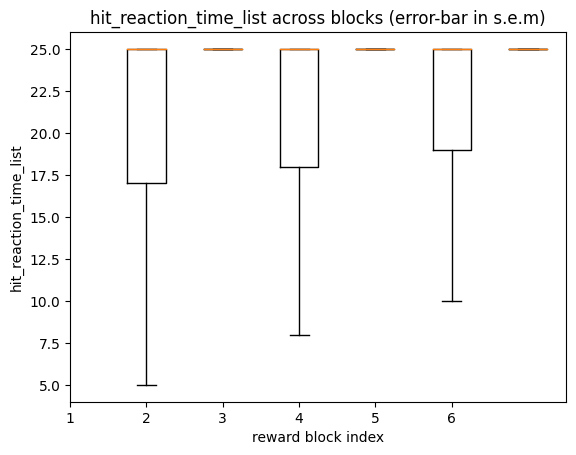

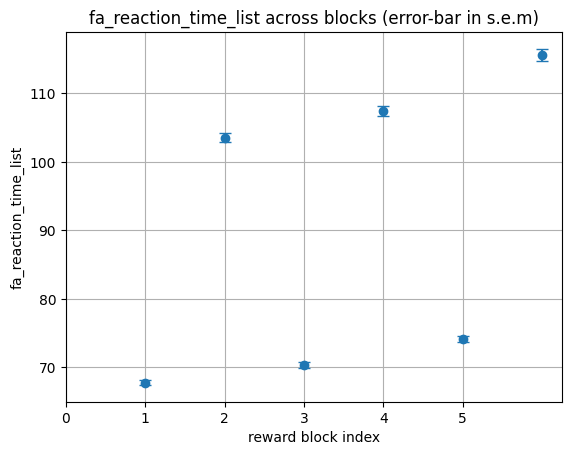

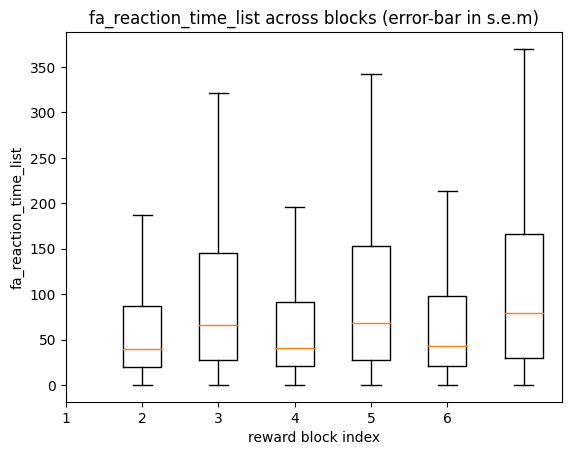

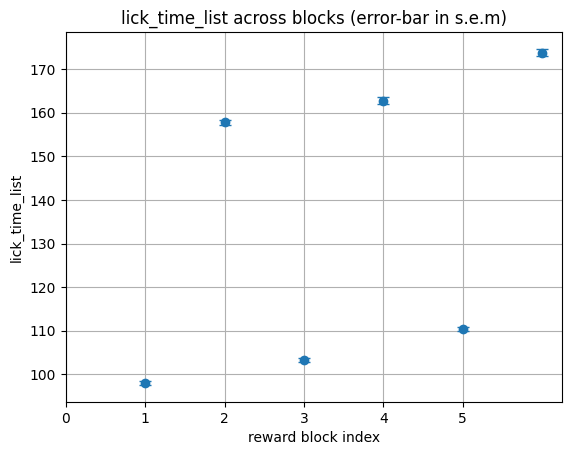

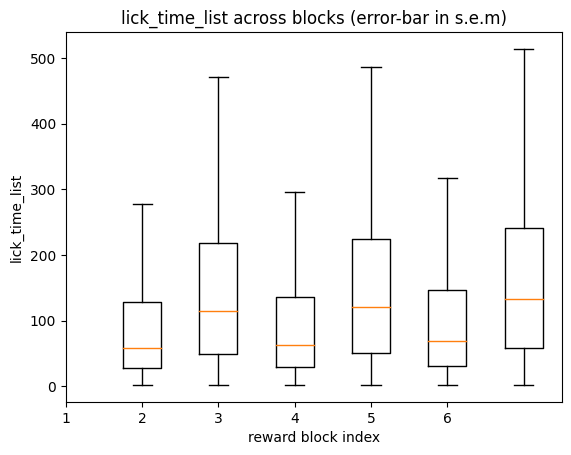

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

one_step_in_seconds = .001

metrics_across_blocks = {}
for mouse in analysis_report.keys(): # for across mice
# for mouse in [list(analysis_report.keys())[17]]: # for single mice
    for reward_block in analysis_report[mouse]:
        if reward_block not in metrics_across_blocks.keys():
            metrics_across_blocks[reward_block] = {}
            metrics_across_blocks[reward_block]['hits_per_trial'] = []
            metrics_across_blocks[reward_block]['misses_per_trial'] = []
            metrics_across_blocks[reward_block]['FAs_per_trial'] = []
            metrics_across_blocks[reward_block]['hits_per_signal_duration'] = []
            metrics_across_blocks[reward_block]['FAs_per_noise_duration'] = []
            metrics_across_blocks[reward_block]['hit_reaction_time_list'] = []
            metrics_across_blocks[reward_block]['fa_reaction_time_list'] = []
            metrics_across_blocks[reward_block]['lick_time_list'] = []
        hits_per_trial = analysis_report[mouse][reward_block]['hit_count']/analysis_report[mouse][reward_block]['no_trials']
        missess_per_trial = analysis_report[mouse][reward_block]['miss_count']/analysis_report[mouse][reward_block]['no_trials']
        FAs_per_trial = analysis_report[mouse][reward_block]['false_alarm_count']/analysis_report[mouse][reward_block]['no_trials']
        hits_per_signal_duration = analysis_report[mouse][reward_block]['hit_count']/(analysis_report[mouse][reward_block]['signal_time_before_lick'] * one_step_in_seconds)
        FAs_per_noise_duration = analysis_report[mouse][reward_block]['false_alarm_count']/(analysis_report[mouse][reward_block]['noise_time_before_lick'] * one_step_in_seconds)
        metrics_across_blocks[reward_block]['hits_per_trial'].append(hits_per_trial)
        metrics_across_blocks[reward_block]['misses_per_trial'].append(missess_per_trial)
        metrics_across_blocks[reward_block]['FAs_per_trial'].append(FAs_per_trial)
        metrics_across_blocks[reward_block]['hits_per_signal_duration'].append(hits_per_signal_duration)
        metrics_across_blocks[reward_block]['FAs_per_noise_duration'].append(FAs_per_noise_duration)
        metrics_across_blocks[reward_block]['hit_reaction_time_list'] += analysis_report[mouse][reward_block]['hit_reaction_time_list']
        metrics_across_blocks[reward_block]['fa_reaction_time_list'] += analysis_report[mouse][reward_block]['fa_reaction_time_list']
        metrics_across_blocks[reward_block]['lick_time_list'] += analysis_report[mouse][reward_block]['lick_time_list']


metrics = ['hits_per_trial', 'misses_per_trial', 'FAs_per_trial', 'hits_per_signal_duration', 'FAs_per_noise_duration','hit_reaction_time_list','fa_reaction_time_list','lick_time_list']
block_indices_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
for metric in metrics:
    plt.figure()
    mean_list = [np.mean(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    sem_list = [np.std(metrics_across_blocks[block_ind][metric])/np.sqrt(len(metrics_across_blocks[block_ind][metric])) for block_ind in block_indices_list]
    # std_list = [np.std(metrics_across_blocks[block_ind][metric]) for block_ind in block_indices_list]
    plt.errorbar([float(block_ind) for block_ind in block_indices_list], mean_list, yerr= sem_list, fmt='o', markersize=6, capsize=4)
    # plt.errorbar([float(block_ind) for block_ind in block_indices_list], mean_list, yerr= std_list, fmt='o', markersize=6, capsize=4)
    plt.xlabel('reward block index')
    plt.ylabel(metric)
    plt.title(metric + f' across blocks (error-bar in s.e.m)')
    # plt.title(metric + f' across blocks (error-bar in s.t.d)')
    plt.xticks(np.arange(len(block_indices_list)))  # Set x-axis labels to column indices
    plt.grid()
    plt.show()

    plt.figure()
    plt.boxplot([metrics_across_blocks[block_ind][metric] for block_ind in block_indices_list], showfliers=False)
    plt.xticks(np.arange(len(block_indices_list)))  # Set x-axis labels to column indices
    plt.xlabel('reward block index')
    plt.ylabel(metric)
    plt.title(metric + f' across blocks (error-bar in s.e.m)')
    plt.show()

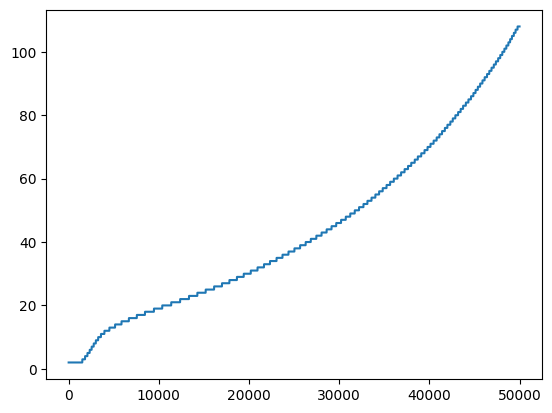

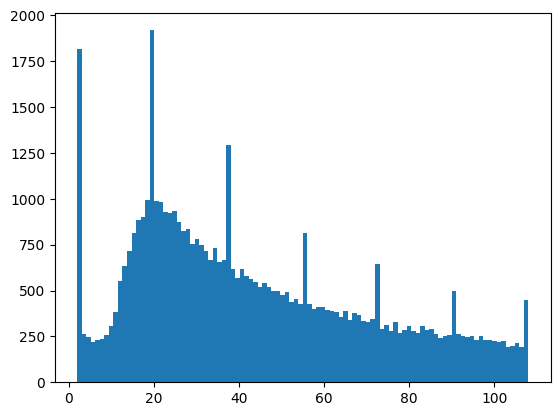

[  2.     3.06   4.12   5.18   6.24   7.3    8.36   9.42  10.48  11.54
  12.6   13.66  14.72  15.78  16.84  17.9   18.96  20.02  21.08  22.14
  23.2   24.26  25.32  26.38  27.44  28.5   29.56  30.62  31.68  32.74
  33.8   34.86  35.92  36.98  38.04  39.1   40.16  41.22  42.28  43.34
  44.4   45.46  46.52  47.58  48.64  49.7   50.76  51.82  52.88  53.94
  55.    56.06  57.12  58.18  59.24  60.3   61.36  62.42  63.48  64.54
  65.6   66.66  67.72  68.78  69.84  70.9   71.96  73.02  74.08  75.14
  76.2   77.26  78.32  79.38  80.44  81.5   82.56  83.62  84.68  85.74
  86.8   87.86  88.92  89.98  91.04  92.1   93.16  94.22  95.28  96.34
  97.4   98.46  99.52 100.58 101.64 102.7  103.76 104.82 105.88 106.94
 108.  ]
[1815.  264.  249.  217.  230.  234.  259.  309.  383.  553.  631.  714.
  815.  882.  903.  994. 1918.  987.  982.  928.  923.  934.  874.  823.
  833.  755.  781.  749.  717.  664.  729.  658.  664. 1291.  615.  568.
  615.  581.  561.  545.  517.  539.  521.  497.  498.  477.  

In [176]:
block_ind = '1.0'
bins = 100
# bins = 108
max_sorted_samples = 50000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
hist, bins, _ = plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

print(bins)
print(hist)

In [184]:
def count_elements_in_range(lst, lower_bound, upper_bound):
    count = 0
    for element in lst:
        if lower_bound <= element < upper_bound:
            count += 1
    return count

# Example usage:
lower_bound = 18.96
upper_bound = 20.02
count = count_elements_in_range(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], lower_bound, upper_bound)
print("Number of elements between", lower_bound, "and", upper_bound, ":", count)


Number of elements between 18.96 and 20.02 : 1918


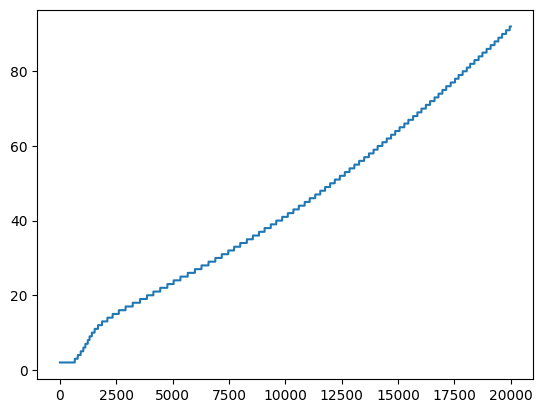

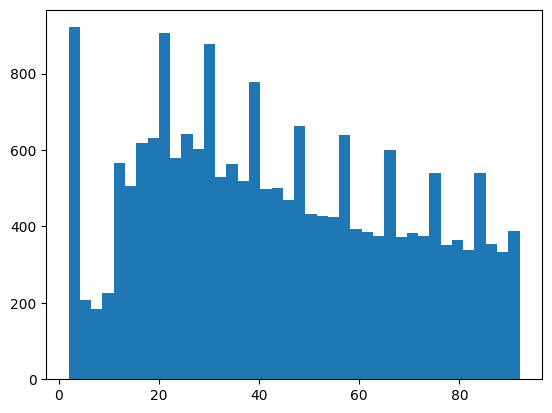

In [66]:
block_ind = '2.0'
bins = 40
max_sorted_samples = 20000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

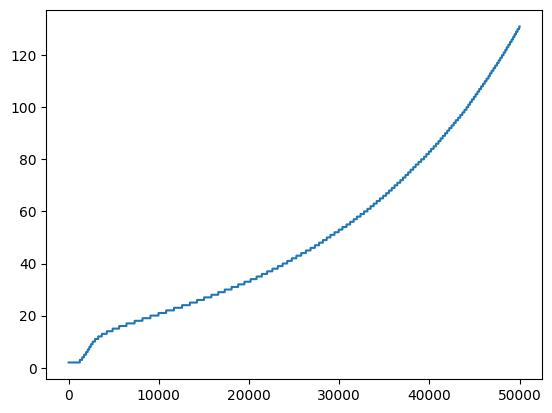

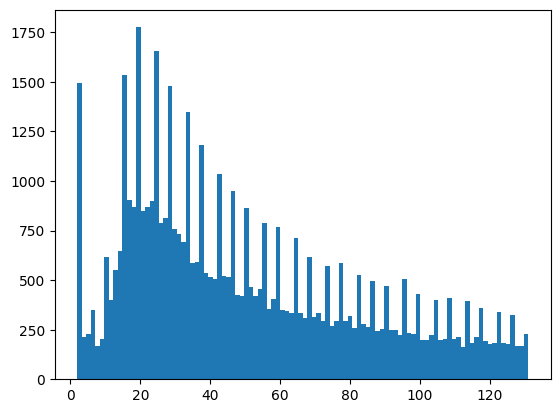

In [62]:
block_ind = '3.0'
bins = 100
max_sorted_samples = 50000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

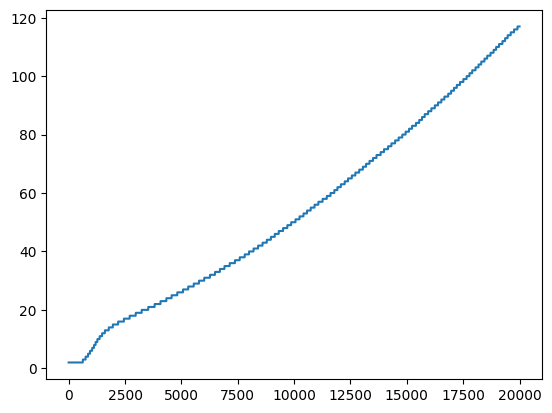

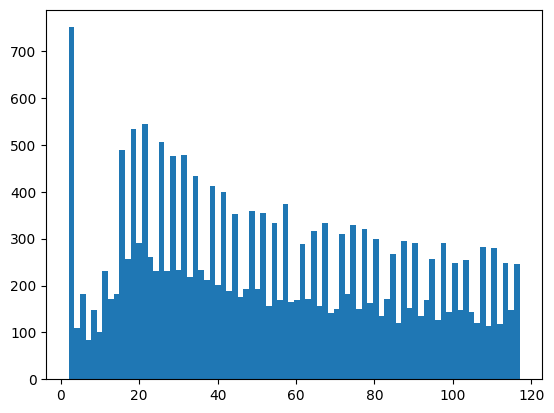

In [144]:
block_ind = '4.0'
# bins = 100
bins = 80
max_sorted_samples = 20000


plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

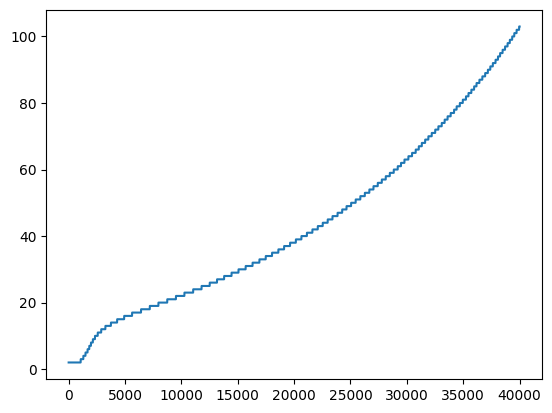

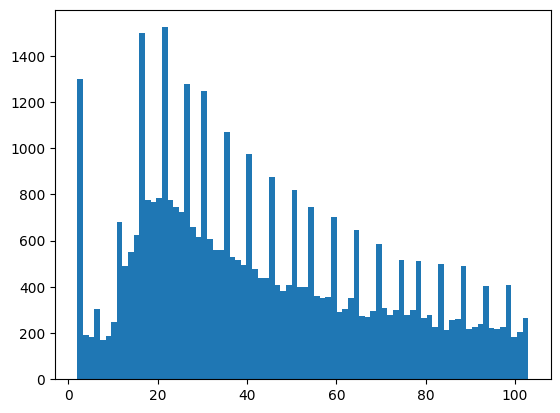

In [143]:
block_ind = '5.0'
bins = 80
max_sorted_samples = 40000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

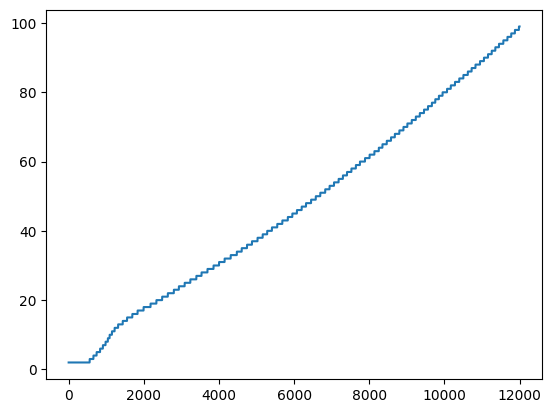

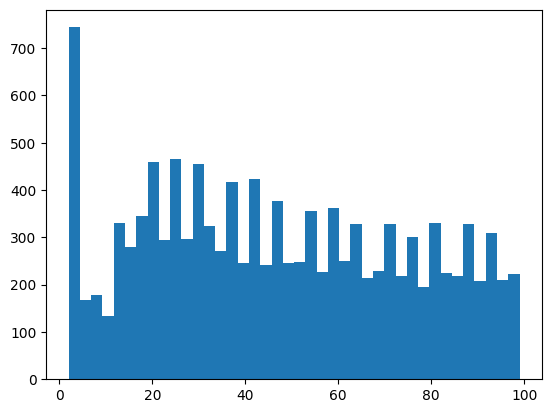

In [90]:
block_ind = '6.0'
# bins = 30
bins = 40
max_sorted_samples = 12000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

In [ ]:
# Trying things out

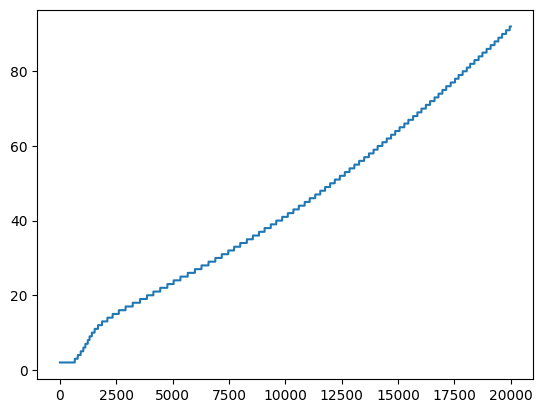

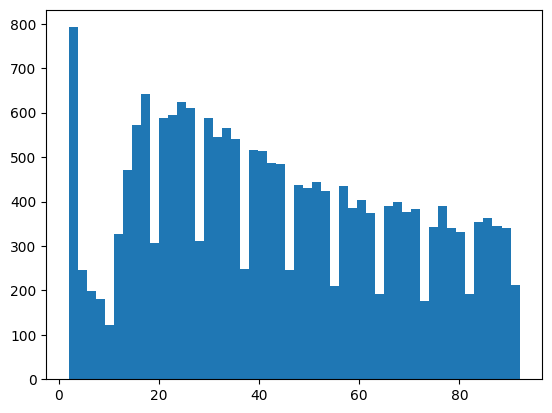

In [104]:
block_ind = '2.0'
bins = 50
max_sorted_samples = 20000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()

In [93]:
max(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])

92

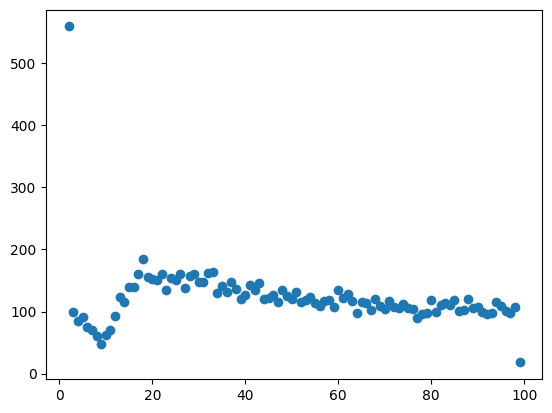

In [122]:
# block_ind = '1.0'
# max_sorted_samples = 40000

# block_ind = '2.0'
# max_sorted_samples = 20000

# block_ind = '3.0'
# max_sorted_samples = 50000

# block_ind = '4.0'
# max_sorted_samples = 20000

# block_ind = '5.0'
# max_sorted_samples = 40000

# block_ind = '6.0'
# bins = 40
# max_sorted_samples = 12000



temp_list = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples]

def create_count_dictionary(integer_list):
    count_dict = {}
    for integer in integer_list:
        if integer in count_dict:
            count_dict[integer] += 1
        else:
            count_dict[integer] = 1
    return count_dict

result_dict = create_count_dictionary(temp_list)

time_list = []
count_list = []
for time, count in result_dict.items():
    time_list.append(time)
    count_list.append(count)
plt.scatter(time_list, count_list)
plt.show()

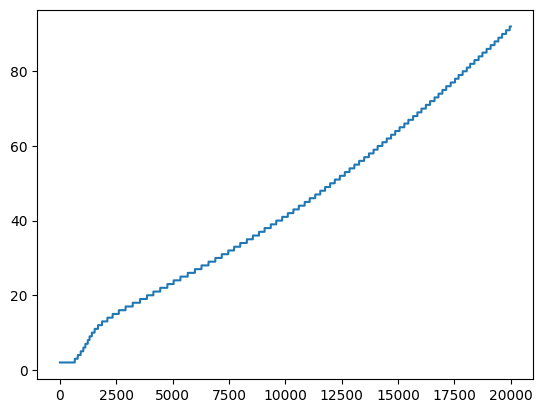

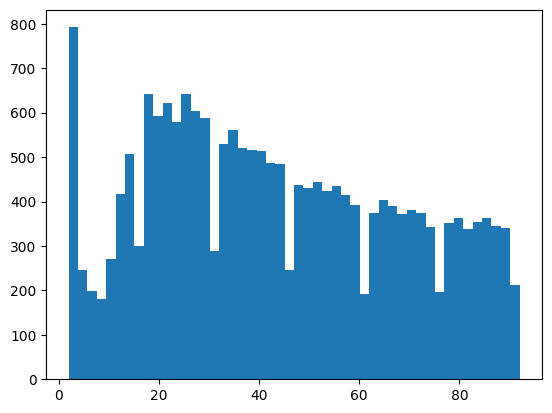

[ 2.     3.875  5.75   7.625  9.5   11.375 13.25  15.125 17.    18.875
 20.75  22.625 24.5   26.375 28.25  30.125 32.    33.875 35.75  37.625
 39.5   41.375 43.25  45.125 47.    48.875 50.75  52.625 54.5   56.375
 58.25  60.125 62.    63.875 65.75  67.625 69.5   71.375 73.25  75.125
 77.    78.875 80.75  82.625 84.5   86.375 88.25  90.125 92.   ]
[792. 246. 198. 181. 271. 417. 507. 299. 642. 592. 621. 579. 642. 603.
 588. 288. 530. 562. 520. 517. 513. 486. 484. 245. 438. 430. 444. 424.
 436. 415. 392. 193. 375. 404. 389. 371. 382. 374. 343. 197. 352. 364.
 339. 355. 363. 344. 341. 212.]


In [138]:
block_ind = '2.0'
bins = 48
max_sorted_samples = 20000

plt.plot(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples])
plt.show()
hist, bins, _ = plt.hist(np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples], bins = bins)
plt.show()
print(bins)
print(hist)

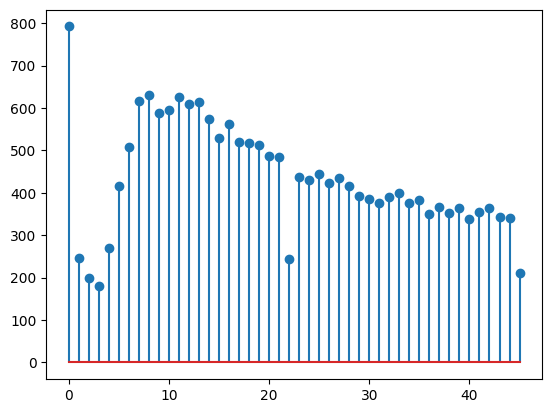

In [134]:
plt.stem(hist)
plt.show()

Highest index of value 200 is: 53352


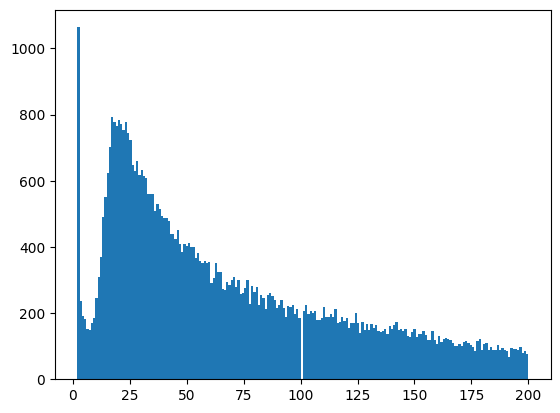

In [163]:
max_lick_time = 200
factor = 1

# block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']
block_ind_list = ['5.0']

def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index

for block_ind in block_ind_list:
    time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))
    max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
    print("Highest index of value", max_lick_time, "is:", max_sorted_samples)
    time_list_selected = time_list_all[:max_sorted_samples]
    plt.figure()
    plt.hist(time_list_selected, bins = int(max_lick_time/factor))
    plt.show()

67437


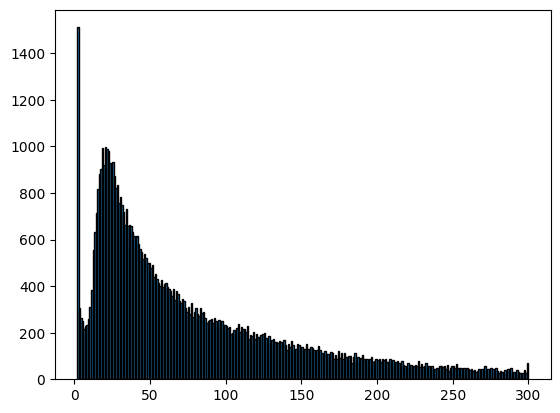

40496


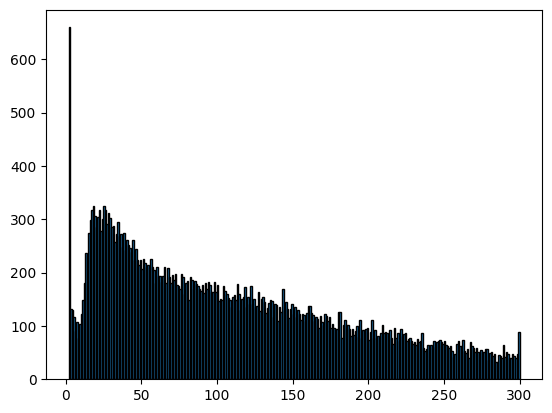

63539


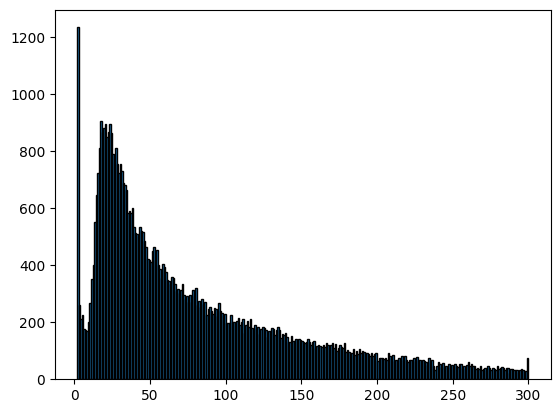

34454


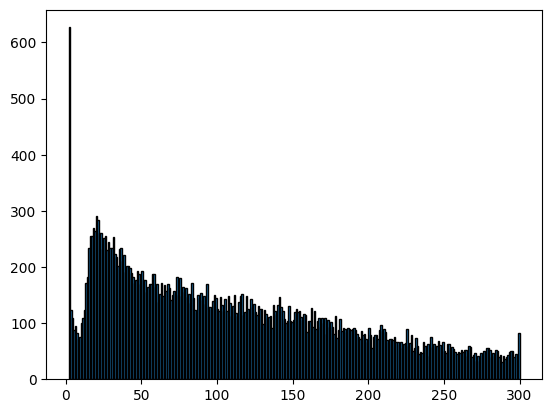

58555


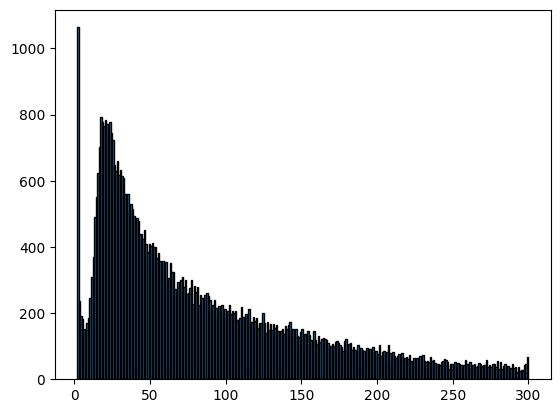

25565


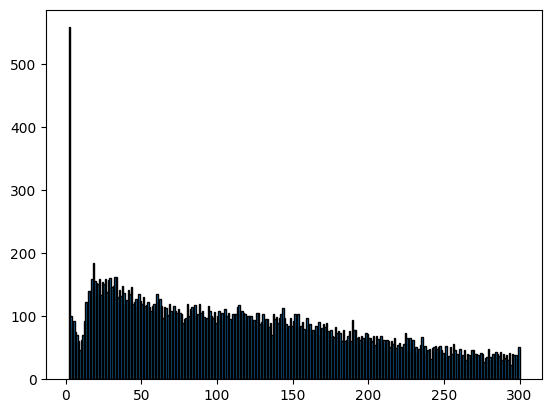

In [197]:
max_lick_time = 300

def highest_index_of_value(lst, value):
    highest_index = -1  
    for i in range(len(lst)):
        if lst[i] == value:
            highest_index = i  
    return highest_index

block_ind_list = ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0']

for block_ind in block_ind_list:
    time_list_all = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))
    max_sorted_samples = highest_index_of_value(time_list_all, max_lick_time)
    print(max_sorted_samples)


    sorted_list = np.sort(np.array(metrics_across_blocks[block_ind]['lick_time_list']))[:max_sorted_samples]
    plt.hist(sorted_list, bins=range(min(sorted_list), max(sorted_list) + 1), edgecolor='black')
    plt.show()


In [192]:
len(sorted_list)

53352

In [193]:
max(sorted_list)

125